In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import math
from matplotlib.scale import FuncScale

from pathlib import Path

from os.path import join
import os
from functools import partial
import pathlib
import shutil

import re


In [2]:
verif_dir = Path("/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed")
verif_files = sorted([p for p in verif_dir.iterdir() if (p != "verif.parquet") and "parquet" in p.name])

df_dict = {p.name: pd.read_parquet(p) for p in verif_files}


In [4]:
bad_keys = []
for k, df in df_dict.items():
    if any(df["MAE_C13"] > 100):
        bad_keys.append(k)

0      [8.10026051550544]
1     [8.249280725220114]
2      [8.29303703716413]
3      [8.30724758831553]
4     [8.289433777180038]
5     [8.254466028487592]
6     [8.191041542181019]
7     [8.153292527223325]
8      [8.09904823191102]
9     [8.068246348039626]
10    [8.033213705358223]
11    [8.063983792642611]
12     [8.10868514286939]
13    [8.169191093804674]
14      [8.1998720788585]
15    [8.222766104664311]
16    [8.234421306981409]
17    [8.230092702022393]
18    [8.233707541520861]
19    [118.3767410207669]
20    [8.355651757877137]
21    [8.481074417132108]
22      [8.6293278581961]
23    [8.774988430579375]
Name: MAE_C13, dtype: object

In [11]:
df_list = list(df_dict.values())
columns = [c for c in df_list[0].columns if "FFT" not in c]

In [12]:
del_keys = []
for k, df in df_dict.items():
    if any(df["RMSE_C13"] > 1000):
        del_keys.append(k)

for k in del_keys:
    df_dict.pop(k)

for k, df in df_dict.items():
    if any(df["RMSE_C13"] > 1000):
        print(k)

In [14]:
for k in del_keys:
    os.remove(join(verif_dir, k))

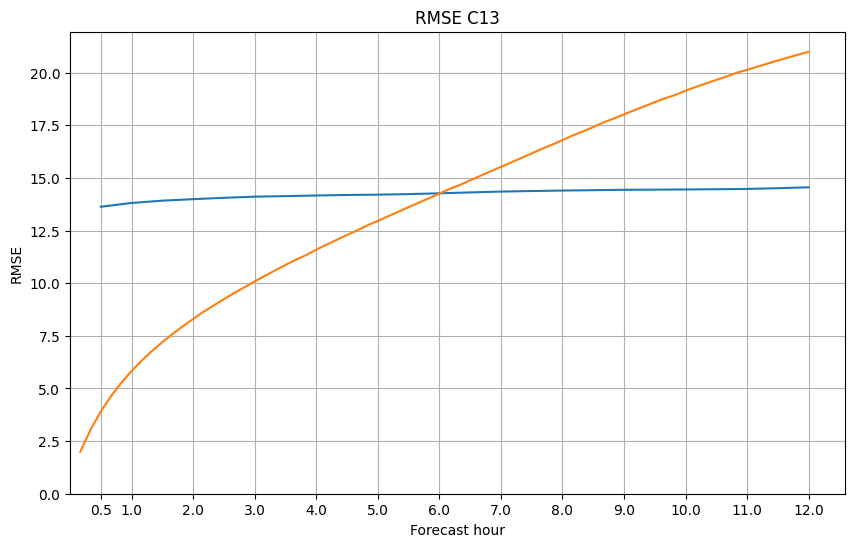

In [5]:
# df_dict = {key: df[columns].clip(-50,50) for key,df in df_dict.items()}

# take nanmean of all verifications and save
def nanmean_cell(*values):
    arrays = [np.atleast_1d(np.array(v, dtype=float)) for v in values]
    result = np.nanmean(arrays, axis=0)
    return result[0] if result.size == 1 else result

dfs = list(df_dict.values())
df = pd.DataFrame(
    {col: [nanmean_cell(*values) for values in zip(*[df[col] for df in dfs])]
    for col in dfs[0].columns},
    index=dfs[0].index
)
df.attrs["init_times"] = list(df_dict.keys())

dfs_all = {"30m_mpas": list(df_dict.values()),
          "10m_big": [pd.read_parquet(p) for p in Path("/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts/").iterdir() if "parquet" in p.name]}
dfs = {"30m_mpas": df,
      "10m_big": pd.read_parquet("/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts/verif.parquet")}


colors = {}
linestyles= {}

def plot_1d_metric(metric, channel, right_lim=None, top_lim=None):
    col_name = f"{metric}_C{channel:02}"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for model, df in dfs.items():
        timestep = int(model[:2]) / 60.
        ax.plot(df.forecast_step * timestep, df[col_name], label=model, color=colors.get(model, None), linestyle=linestyles.get(model, None))
    
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    # ax.legend()

    ax.set_xlim(left=0.0,right=right_lim)
    if metric != "ME":
        ax.set_ylim(bottom=0.0, top=top_lim)
    else:
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} C{channel:02}")
    plt.show()

plot_1d_metric("RMSE", 13)

In [6]:
df.to_parquet(join(verif_dir, "verif.parquet"))

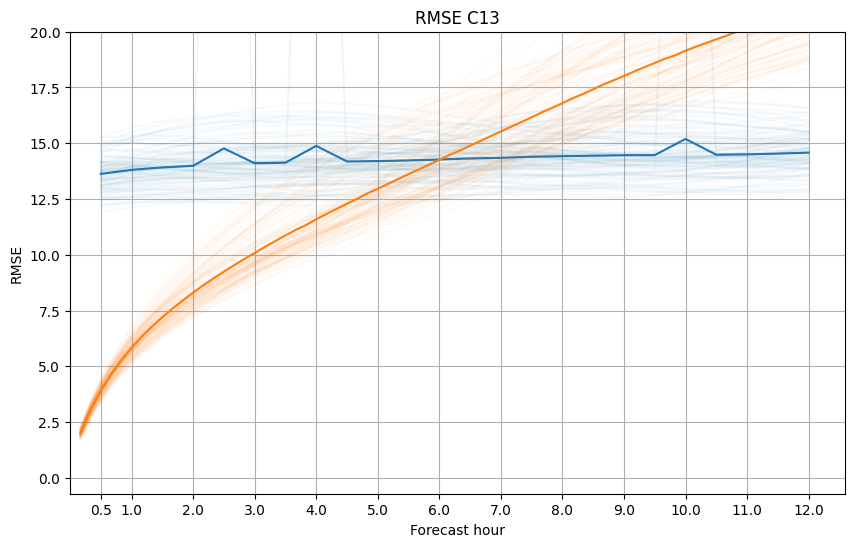

In [62]:
def plot_1d_envelope(metric, channel, right_lim=None, top_lim=None, bot_lim=None):
    col_name = f"{metric}_C{channel:02}"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for model, df in dfs.items():
        timestep = int(model[:2]) / 60.
        p = ax.plot(df.forecast_step * timestep, df[col_name], label=model, color=colors.get(model, None), linestyle=linestyles.get(model, None))
        color = p[0].get_color()

        all_dfs = dfs_all[model]
        for df in all_dfs:
            ax.plot(df.forecast_step * timestep, df[col_name], color=color, alpha=0.03)
        
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    # ax.legend()

    ax.set_xlim(left=0.0,right=right_lim)
    ax.set_ylim(bottom=bot_lim, top=top_lim)
    if metric == "ME":
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} C{channel:02}")
    plt.show()

plot_1d_envelope("RMSE", 13, top_lim=20)

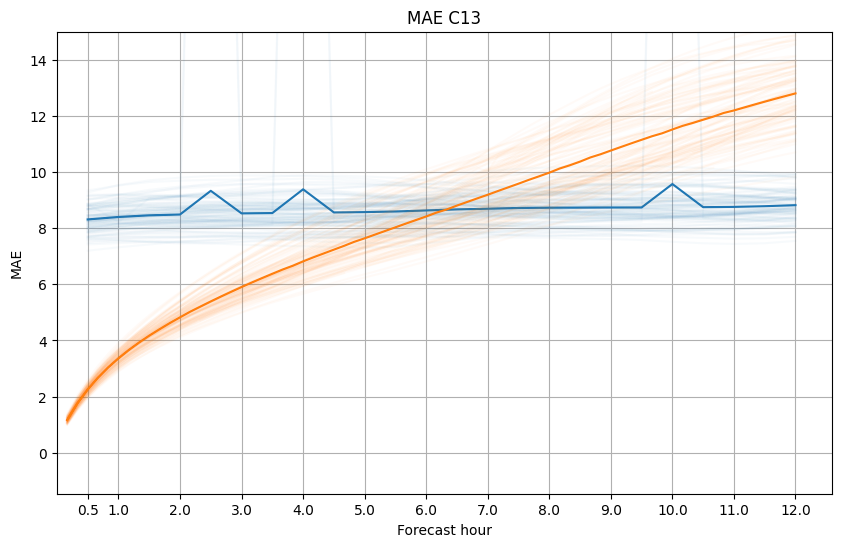

In [63]:
plot_1d_envelope("MAE", 13, top_lim=15)

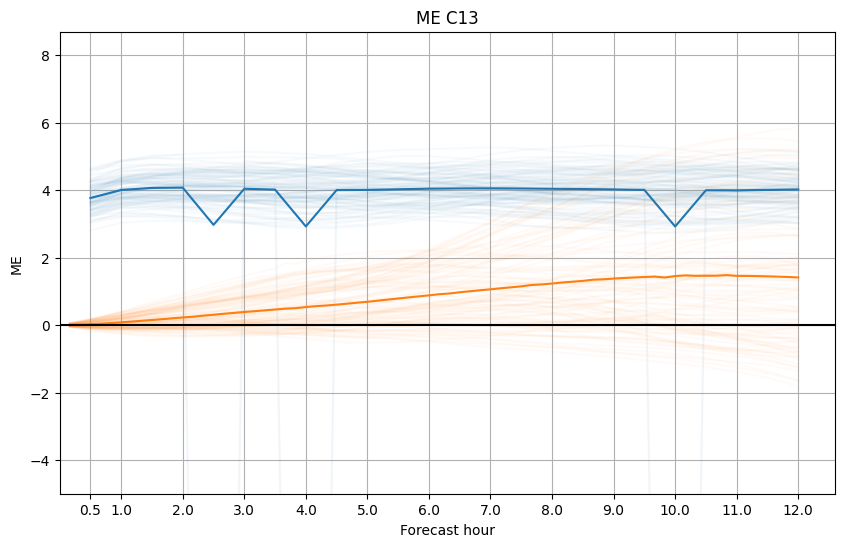

In [64]:
plot_1d_envelope("ME", 13, bot_lim=-5)

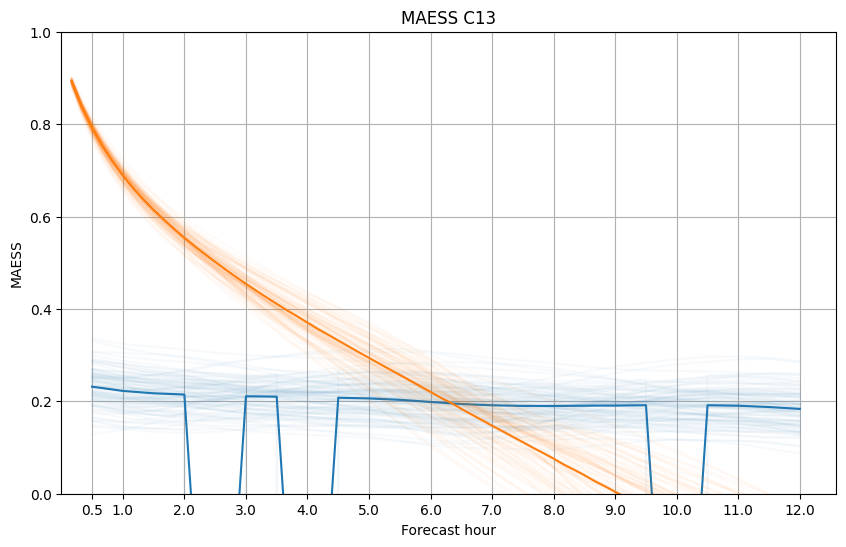

In [23]:
plot_1d_envelope("MAESS", 13, top_lim=1)

# double check RMSE calcs

In [25]:
zarr_ds = xr.open_dataset("/glade/derecho/scratch/dkimpara/goes-cloud-dataset/goes_10km_2025.zarr")

In [43]:
mpas = xr.open_dataset("/glade/derecho/scratch/dkimpara/goes_10km_train/mpas_forecasts_fixed/2025-06-25T12:00:00/2025-06-25T12:25:00.nc")

In [44]:
pred_ds = mpas.BT_or_R
true_ds = zarr_ds.sel(t=pred_ds.t, method="nearest").BT_or_R

In [45]:
pred_ds.t - true_ds.t

<xarray.DataArray 't' (t: 0)> Size: 0B
array([], dtype='timedelta64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 0B

RMSE: 13.642198399209294


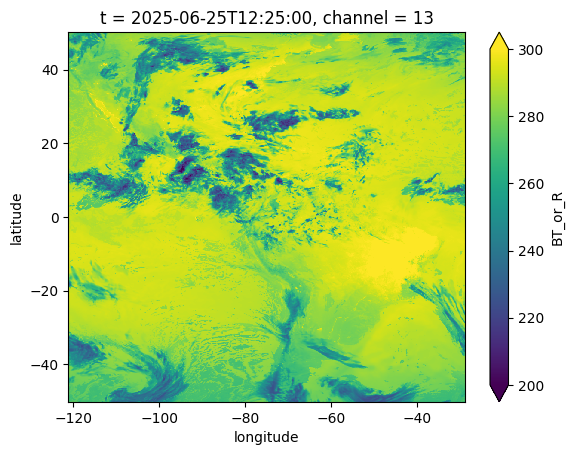

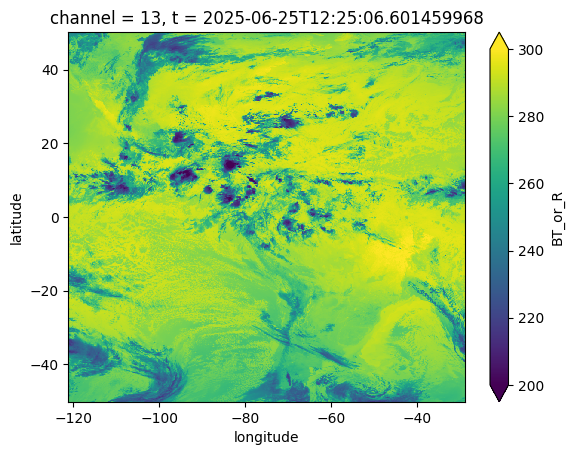

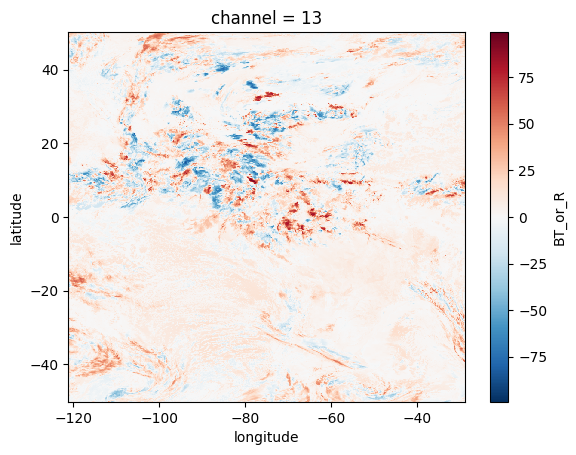

In [49]:
pred_13, true_13 = pred_ds.sel(channel=13).isel(t=0), true_ds.sel(channel=13).isel(t=0)

print(f"RMSE: {float(np.sqrt(((pred_13 - true_13) ** 2).mean()))}")

pred_13.plot(vmin=200, vmax=300)
plt.show()
true_13.plot(vmin=200, vmax=300)
plt.show()

(pred_13 - true_13).plot()
plt.show()